# Smartphone Addiction Prediction — Playground Series S6E8

**Approach**: EDA → correlation-aware missing value imputation → categorical encoding → 
three-model ensemble (CatBoost, XGBoost, LightGBM) with grid-searched blend weights.

**Public LB score**: 0.9644 ROC-AUC

## Highlights

- **Missing value strategy**: instead of filling numeric gaps with plain median/mean, 
  I first mapped out pairwise correlations between features (several pairs above 0.5, 
  one as high as 0.80) and used `IterativeImputer` to predict missing values from 
  related columns rather than ignoring that structure.
- **Careful train/test separation**: all imputation and encoding statistics 
  (mode, median, learned mappings) are fit on train only and applied to test — 
  no information leakage between the two sets.
- **Model ensemble**: trained CatBoost, XGBoost, and LightGBM separately, then found 
  the optimal blend weights via grid search over validation ROC-AUC rather than 
  simple equal-weight averaging.
- **Honest validation**: used a stratified train/validation split throughout, 
  so the reported metrics reflect genuine generalization rather than in-sample fit.

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

## Data Loading

In [2]:
train_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/train.csv')
test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/test.csv')

In [3]:
train_data

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


## EDA

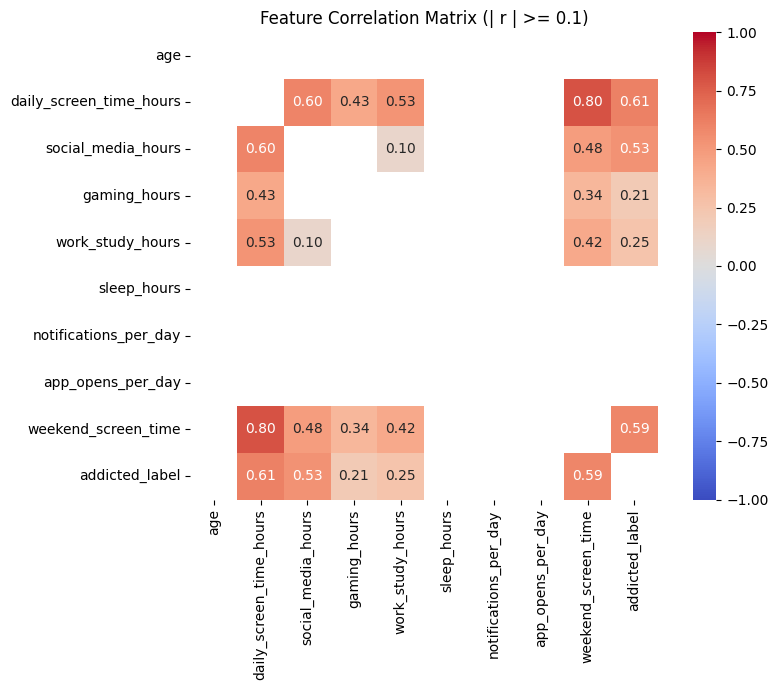

In [4]:
# Define features for correlation matrix
numeric_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
                 'work_study_hours', 'sleep_hours', 'notifications_per_day',
                 'app_opens_per_day', 'weekend_screen_time']

all_cols = numeric_cols + ['addicted_label']
corr_matrix = train_data[all_cols].corr()

# Hide weak correlations (|r| < 0.1) and self-correlations on the diagonal
mask = np.abs(corr_matrix) < 0.1
np.fill_diagonal(mask.values, True) 

# Create the heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            mask=mask, center=0, vmin=-1, vmax=1, square=True)
plt.title('Feature Correlation Matrix (| r | >= 0.1)')
plt.tight_layout()
plt.show()

## Correlation Structure

Before choosing an imputation strategy, I looked at pairwise correlations across 
all numeric features (including the target) to understand how much structure 
was available to exploit.

**Strong (r ≥ 0.5)**
- `daily_screen_time_hours` ↔ `weekend_screen_time` — 0.800
- `daily_screen_time_hours` ↔ `addicted_label` — 0.611
- `social_media_hours` ↔ `daily_screen_time_hours` — 0.596
- `addicted_label` ↔ `weekend_screen_time` — 0.590
- `social_media_hours` ↔ `addicted_label` — 0.532
- `daily_screen_time_hours` ↔ `work_study_hours` — 0.526

**Moderate (0.3 ≤ r < 0.5)**
- `social_media_hours` ↔ `weekend_screen_time` — 0.478
- `gaming_hours` ↔ `daily_screen_time_hours` — 0.429
- `work_study_hours` ↔ `weekend_screen_time` — 0.418
- `gaming_hours` ↔ `weekend_screen_time` — 0.342

**Weak (r < 0.3)**
- `gaming_hours` ↔ `addicted_label` — 0.205
- `social_media_hours` ↔ `work_study_hours` — 0.101

**Takeaway**: screen-time-related features (`daily_screen_time_hours`, 
`weekend_screen_time`, `social_media_hours`) form a tightly correlated cluster 
and are also the strongest predictors of `addicted_label`. This structure is 
exactly what `IterativeImputer` can exploit — filling a missing value in one 
of these columns using the others is far more informative than a plain median.

## Filling Missing Values

### 1. Numerical columns

In [5]:
train_data.isna().sum()

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

In [6]:
test_data.isna().sum()

id                             0
age                        17138
daily_screen_time_hours    32788
social_media_hours         47397
gaming_hours               59420
work_study_hours           27777
sleep_hours                22455
notifications_per_day      34221
app_opens_per_day          25705
weekend_screen_time        50697
gender                     14212
stress_level               19626
academic_work_impact       25721
dtype: int64

In [7]:
# Fill missing values by medians columns with weak correlations

median_cols = ['age', 'notifications_per_day', 'app_opens_per_day', 'sleep_hours']

for col in median_cols:
    train_data[col]= train_data[col].fillna(train_data[col].median())
    test_data[col]= test_data[col].fillna(train_data[col].median())

In [8]:
# Impute missing values using IterativeImputer

# Columns that have correlations with each other
corr_numeric_cols = ['daily_screen_time_hours', 'weekend_screen_time', 'social_media_hours', 'work_study_hours', 'gaming_hours']

# Create & fit the imputer
imputer = IterativeImputer(random_state=42)
imputer.fit(train_data[corr_numeric_cols])

# Transform train & test data
train_data[corr_numeric_cols] = imputer.transform(train_data[corr_numeric_cols])
test_data[corr_numeric_cols] = imputer.transform(test_data[corr_numeric_cols])

train_data[corr_numeric_cols + ['addicted_label']].corr()

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,daily_screen_time_hours,weekend_screen_time,social_media_hours,work_study_hours,gaming_hours,addicted_label
daily_screen_time_hours,1.000000,0.832932,0.631564,0.549339,0.462395,0.603257
weekend_screen_time,0.832932,1.000000,0.522925,0.442499,0.379892,0.584789
social_media_hours,0.631564,0.522925,1.000000,0.109301,0.112970,0.528233
work_study_hours,0.549339,0.442499,0.109301,1.000000,0.053408,0.257608
gaming_hours,0.462395,0.379892,0.112970,0.053408,1.000000,0.223589
addicted_label,0.603257,0.584789,0.528233,0.257608,0.223589,1.000000


### 2. Categorical columns

In [9]:
categorical_cols = ['stress_level', 'gender', 'academic_work_impact']

# Fill missing values using mode
for col in categorical_cols:
    train_data[col] = train_data[col].fillna(train_data[col].mode()[0])
    test_data[col] = test_data[col].fillna(train_data[col].mode()[0])

In [10]:
train_data.isna().sum()

id                         0
age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
gender                     0
stress_level               0
academic_work_impact       0
addicted_label             0
dtype: int64

In [11]:
test_data.isna().sum()

id                         0
age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
gender                     0
stress_level               0
academic_work_impact       0
dtype: int64

## Encoding

In [12]:
# One-Hot encoding ('gender' column)
train_data = pd.get_dummies(train_data, columns=['gender'], drop_first=True) 
test_data = pd.get_dummies(test_data, columns=['gender'], drop_first=True)

In [13]:
# Ordinal encoding ('stress_level' column)
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
train_data['stress_level_encoded'] = train_data['stress_level'].map(stress_map)
test_data['stress_level_encoded'] = test_data['stress_level'].map(stress_map)

In [14]:
# Ordinal encoding ('academic_work_impact' column)
academic_work_impact_map = {'No': 0, 'Yes': 1}
train_data['academic_work_impact_encoded'] = train_data['academic_work_impact'].map(academic_work_impact_map)
test_data['academic_work_impact_encoded'] = test_data['academic_work_impact'].map(academic_work_impact_map)

In [15]:
# Drop useless columns
train_data = train_data.drop(columns=['stress_level', 'academic_work_impact'], axis=1)
test_data = test_data.drop(columns=['stress_level', 'academic_work_impact'], axis=1)

## Train-Test Splitting

In [16]:
X = train_data.drop(columns=['addicted_label', 'id'])
y = train_data['addicted_label']
X_test = test_data.drop(columns=['id'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Models Creating

In [17]:
model_cat = CatBoostClassifier(iterations=500, random_state=42, verbose=0)
model_cat.fit(X_train, y_train)

model_lgbm = LGBMClassifier(n_estimators=500, random_state=42)
model_lgbm.fit(X_train, y_train)

model_xgb = XGBClassifier(n_estimators=500, random_state=42)
model_xgb.fit(X_train, y_train)

proba_cat = model_cat.predict_proba(X_val)[:, 1]
proba_xgb = model_xgb.predict_proba(X_val)[:, 1]
proba_lgbm = model_lgbm.predict_proba(X_val)[:, 1]

print("CatBoost:", roc_auc_score(y_val, proba_cat))
print("XGBoost:", roc_auc_score(y_val, proba_xgb))
print("LightGBM:", roc_auc_score(y_val, proba_lgbm))

[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.042793 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1950
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709424 -> initscore=0.892589
[LightGBM] [Info] Start training from score 0.892589
CatBoost: 0.9612255136347316
XGBoost: 0.9615027170050955
LightGBM: 0.9589898916097341


In [18]:
# Find the best weights for ensemble & ROC-AUC score
best_score = 0
best_weights = None

for w1 in np.arange(0, 1.05, 0.05):
    for w2 in np.arange(0, 1.05 - w1, 0.05):
        w3 = 1 - w1 - w2
        combined = w1 * proba_cat + w2 * proba_xgb + w3 * proba_lgbm
        score = roc_auc_score(y_val, combined)
        if score > best_score:
            best_score = score
            best_weights = (w1, w2, w3)

print(f"\nThe best weights (cat, xgb, lgbm): {best_weights}")
print(f"The best ensemble ROC-AUC: {best_score:.4f}")


The best weights (cat, xgb, lgbm): (np.float64(0.5), np.float64(0.5), np.float64(0.0))
The best ensemble ROC-AUC: 0.9625


In [19]:
# Fit final models
model_cat_final = CatBoostClassifier(iterations=500, random_state=42, verbose=0)
model_cat_final.fit(X, y)

model_xgb_final = XGBClassifier(n_estimators=500, random_state=42)
model_xgb_final.fit(X, y)

model_lgbm_final = LGBMClassifier(n_estimators=500, random_state=42)
model_lgbm_final.fit(X, y)

test_proba_cat = model_cat_final.predict_proba(X_test)[:, 1]
test_proba_xgb = model_xgb_final.predict_proba(X_test)[:, 1]
test_proba_lgbm = model_lgbm_final.predict_proba(X_test)[:, 1]

w1, w2, w3 = best_weights
final_proba = w1 * test_proba_cat + w2 * test_proba_xgb + w3 * test_proba_lgbm

[LightGBM] [Info] Number of positive: 490474, number of negative: 200895
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1949
[LightGBM] [Info] Number of data points in the train set: 691369, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709424 -> initscore=0.892590
[LightGBM] [Info] Start training from score 0.892590


## Submission 

In [20]:
submission = pd.DataFrame({
    'id': test_data['id'],
    'addicted_label': final_proba 
})

submission.to_csv('submission.csv', index=False)
print(submission.head())

       id  addicted_label
0  691369        0.999449
1  691370        0.958678
2  691371        0.916961
3  691372        0.990780
4  691373        0.998947
